# Gradient-Boosting Decision Tree
**Gradient-Boosting Decision Tree (GBDT)**: boosting algorithm that fits successive decision trees on the residual errors of the preceding tree. GBDT tries to refine its predictions with each successive tree by addressing the errors specifically made by the previous learner. This differs from AdaBoost which assigns weights to specific samples.

In [2]:
import pandas as pd
import numpy as np


def generate_data(n_samples=50):
    """Generate synthetic dataset. Returns `data_train`, `data_test`,
    `target_train`."""
    x_max, x_min = 1.4, -1.4
    rng = np.random.default_rng(0)  # Create a random number generator
    x = rng.uniform(x_min, x_max, size=(n_samples,))
    noise = rng.normal(size=(n_samples,)) * 0.3
    y = x**3 - 0.5 * x**2 + noise

    data_train = pd.DataFrame(x, columns=["Feature"])
    data_test = pd.DataFrame(
        np.linspace(x_max, x_min, num=300), columns=["Feature"]
    )
    target_train = pd.Series(y, name="Target")

    return data_train, data_test, target_train


data_train, data_test, target_train = generate_data()

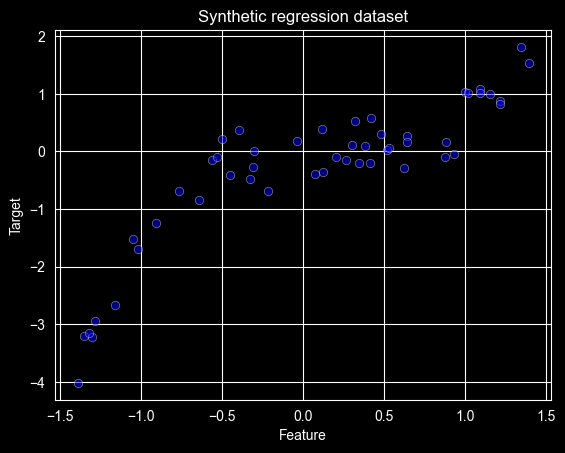

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(
    x=data_train["Feature"], y=target_train, color="blue", alpha=0.5
)
_ = plt.title("Synthetic regression dataset")

In [5]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(max_depth=3, random_state=0)
tree.fit(data_train, target_train)

target_train_predicted = tree.predict(data_train)
target_test_predicted = tree.predict(data_test)

In [8]:
def plot_decision_tree_with_residuals(y_train, y_train_pred, y_test_pred):
    """Plot the synthetic data, predictions, and residuals for a decision tree.
    Handles are returned to allow custom legends for the plot."""
    _fig_, ax = plt.subplots()
    # plot the data
    sns.scatterplot(
        x=data_train["Feature"], y=y_train, color="blue", alpha=0.5, ax=ax
    )
    # plot the predictions
    line_predictions = ax.plot(data_test["Feature"], y_test_pred, "--")

    # plot the residuals
    for value, true, predicted in zip(
        data_train["Feature"], y_train, y_train_pred
    ):
        lines_residuals = ax.plot(
            [value, value], [true, predicted], color="red"
        )

    handles = [line_predictions[0], lines_residuals[0]]

    return handles, ax

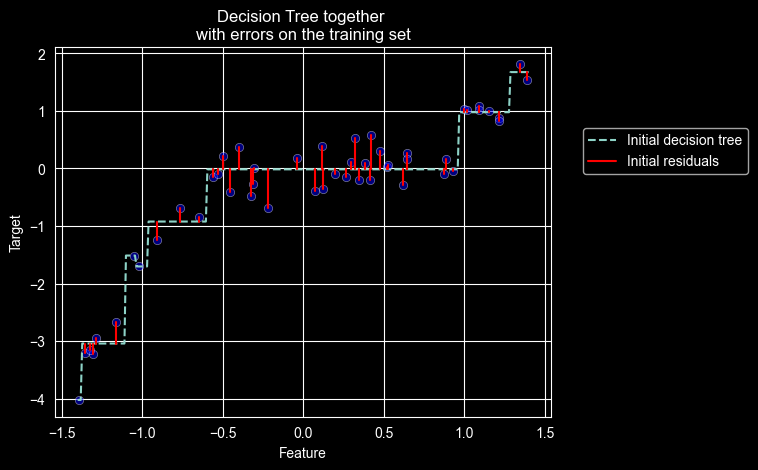

In [9]:
handles, ax = plot_decision_tree_with_residuals(
    target_train, target_train_predicted, target_test_predicted
)
legend_labels = ["Initial decision tree", "Initial residuals"]
ax.legend(handles, legend_labels, bbox_to_anchor=(1.05, 0.8), loc="upper left")
_ = ax.set_title("Decision Tree together \nwith errors on the training set")

Based on our initial underfitted decision tree, we can observe the initial differences between actual and predictions (residuals).

In gradient-boosting, the idea is to create a second tree that tries to predict the *residuals* instead of the *target*.

In [10]:
residuals = target_train - target_train_predicted

tree_residuals = DecisionTreeRegressor(max_depth=5, random_state=0)
tree_residuals.fit(data_train, residuals)

target_train_predicted_residuals = tree_residuals.predict(data_train)
target_test_predicted_residuals = tree_residuals.predict(data_test)

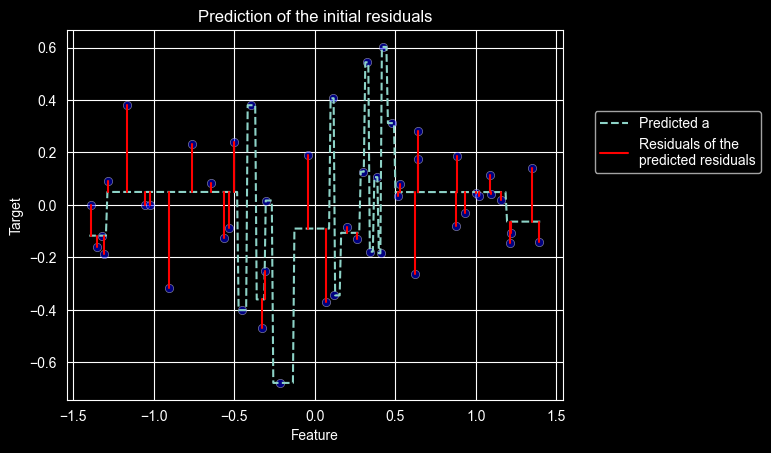

In [11]:
handles, ax = plot_decision_tree_with_residuals(
    residuals,
    target_train_predicted_residuals,
    target_test_predicted_residuals,
)
legend_labels = [
    "Predicted a",
    "Residuals of the\npredicted residuals",
]
ax.legend(handles, legend_labels, bbox_to_anchor=(1.05, 0.8), loc="upper left")
_ = ax.set_title("Prediction of the initial residuals")

This tree manages to fit *some* of the residuals. For illustration purposes, we focus on a specific sample from the training set that can be well predicted using the two successive trees to explain how the predictions of both trees combine.

In [12]:
sample = data_train.iloc[[-7]]
x_sample = sample["Feature"].iloc[0]
target_true = target_train.iloc[-7]
target_true_residual = residuals.iloc[-7]

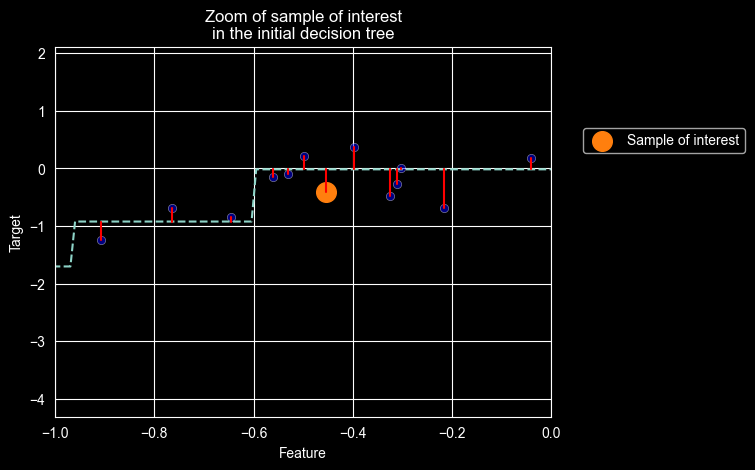

In [13]:
handles, ax = plot_decision_tree_with_residuals(
    target_train, target_train_predicted, target_test_predicted
)
ax.scatter(
    sample, target_true, label="Sample of interest", color="tab:orange", s=200
)
ax.set_xlim([-1, 0])
ax.legend(bbox_to_anchor=(1.05, 0.8), loc="upper left")
_ = ax.set_title("Zoom of sample of interest\nin the initial decision tree")

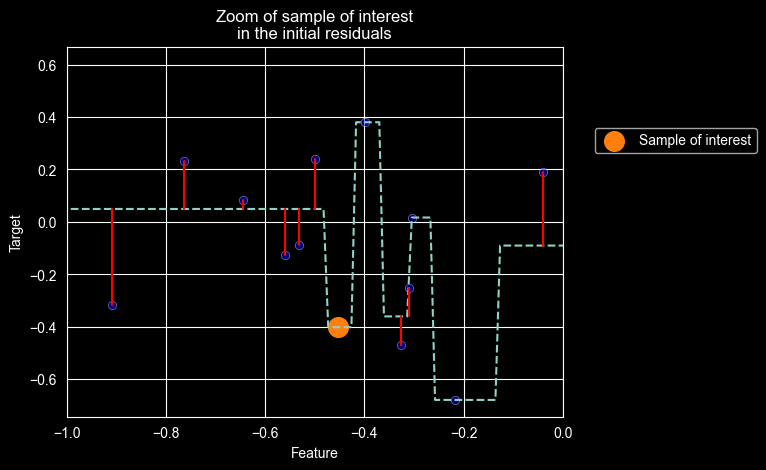

In [14]:
handles, ax = plot_decision_tree_with_residuals(
    residuals,
    target_train_predicted_residuals,
    target_test_predicted_residuals,
)
plt.scatter(
    sample,
    target_true_residual,
    label="Sample of interest",
    color="tab:orange",
    s=200,
)
legend_labels = [
    "Predicted residuals",
    "Residuals of the\npredicted residuals",
]
ax.set_xlim([-1, 0])
ax.legend(bbox_to_anchor=(1.05, 0.8), loc="upper left")
_ = ax.set_title("Zoom of sample of interest\nin the initial residuals")

For this sample of interest, the initial tree is making a small error. When fitting the second tree, the residual is perfectly fitted and predicted.

Below, we simply take the visualization and quantify it. The error of the first tree is relatively small (-0.401), and the error of the second tree is 0.0. Combined, the predictions offset, resulting in an error of 0.0

In [15]:
print(f"True value to predict for f(x={x_sample:.3f}) = {target_true:.3f}")

y_pred_first_tree = tree.predict(sample)[0]
print(
    f"Prediction of the first decision tree for x={x_sample:.3f}: "
    f"y={y_pred_first_tree:.3f}"
)
print(f"Error of the tree: {target_true - y_pred_first_tree:.3f}")

True value to predict for f(x=-0.454) = -0.417
Prediction of the first decision tree for x=-0.454: y=-0.016
Error of the tree: -0.401


In [16]:
print(
    f"Prediction of the residual for x={x_sample:.3f}: "
    f"{tree_residuals.predict(sample)[0]:.3f}"
)

Prediction of the residual for x=-0.454: -0.401


In [17]:
y_pred_first_and_second_tree = (
    y_pred_first_tree + tree_residuals.predict(sample)[0]
)
print(
    "Prediction of the first and second decision trees combined for "
    f"x={x_sample:.3f}: y={y_pred_first_and_second_tree:.3f}"
)
print(f"Error of the tree: {target_true - y_pred_first_and_second_tree:.3f}")

Prediction of the first and second decision trees combined for x=-0.454: y=-0.417
Error of the tree: 0.000


Compared to random forests, random forests can be parallelized and benefit from using multiple CPU cores. However, they tend to lead to very close results.

Overall, gradient boosting can be faster as they build shallow trees that underfit individually and then combine to generalize. Random forests build many deep trees that are overfit, then work to underfit that.